In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("delhi_aqi.csv")
print("--- First 5 Rows of the Dataset ---")
display(df.head())
print("\n--- Dataset Information ---")
print(df.info())

--- First 5 Rows of the Dataset ---


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,01-01-2023 00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,01-01-2023 01:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,01-01-2023 02:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,01-01-2023 03:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,01-01-2023 04:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19



--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    str    
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), str(1)
memory usage: 39.6 KB
None


In [9]:
df.columns = df.columns.str.strip()
numerical_cols = ['PM2.5', 'PM10', 'NO2', 'NH3', 'SO2', 'CO', 'O3', 'AQI']
for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

if 'AQI_Bucket' in df.columns:
    df['AQI_Bucket'] = df['AQI_Bucket'].fillna('Unknown')

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("--- Missing Values Count After Cleaning ---")
print(df.isnull().sum())

--- Missing Values Count After Cleaning ---
date     273
co         0
no         0
no2        0
o3         0
so2        0
pm2_5      0
pm10       0
nh3        0
dtype: int64


In [14]:
print(df.columns.tolist())

['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']


--- Average PM2.5 Level Month-wise ---
Month
January      443.940000
February     698.104167
March        381.810417
April        304.021667
May          423.604583
June         418.079583
July         265.905000
August       354.217917
September    557.806250
October      340.752917
November     450.968750
December     300.427083
Name: pm2_5, dtype: float64




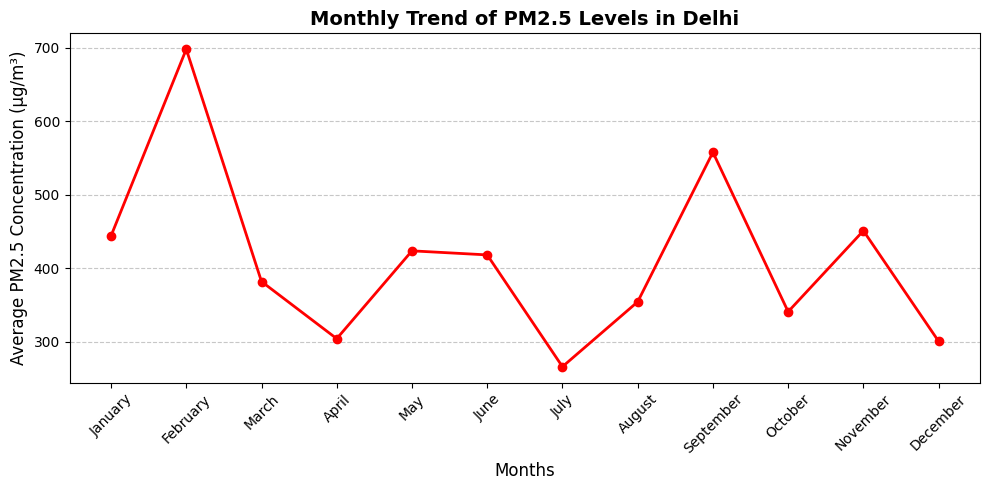

In [34]:
# What is the monthly trend of PM2.5 levels in Delhi?
df['Month'] = df['date'].dt.strftime('%B')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_pm25 = df.groupby('Month')['pm2_5'].mean().reindex(month_order)
print("--- Average PM2.5 Level Month-wise ---")
print(monthly_pm25)

print("\n" + "="*50 + "\n")
plt.figure(figsize=(10, 5))
plt.plot(monthly_pm25.index, monthly_pm25.values, marker='o', color='red', linewidth=2)
plt.title("Monthly Trend of PM2.5 Levels in Delhi", fontsize=14, fontweight='bold')
plt.xlabel("Months", fontsize=12)
plt.ylabel("Average PM2.5 Concentration (µg/m³)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

--- Average Concentration of Each Pollutant ---
co       4203.988542
pm10      474.433229
pm2_5     411.636528
no2        81.469410
so2        64.994583
o3         27.739687
nh3        24.426111
dtype: float64




C:\Users\2025\AppData\Local\Temp\ipykernel_17000\2152671103.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_pollutants.index, y=avg_pollutants.values, palette='Oranges_r')


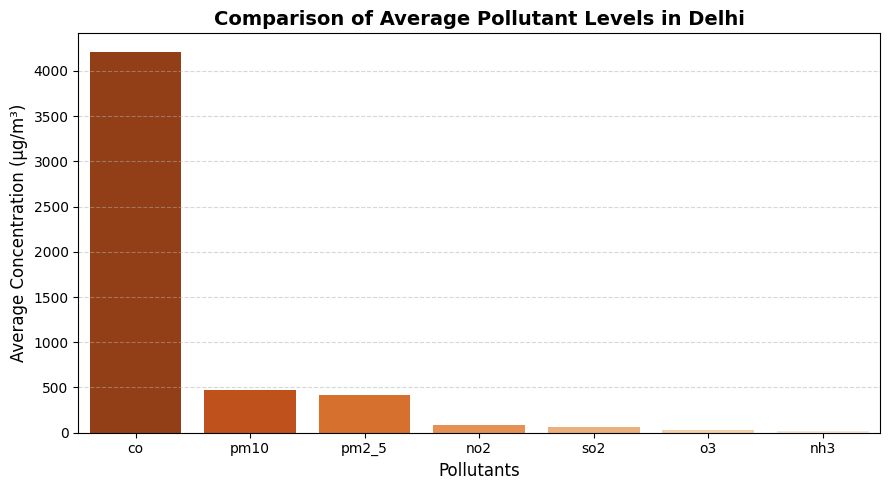

In [35]:
# Which specific pollutant has the highest average concentration level?
pollutants = ['pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3']
avg_pollutants = df[pollutants].mean().sort_values(ascending=False)
print("--- Average Concentration of Each Pollutant ---")
print(avg_pollutants)
print("\n" + "="*50 + "\n")
plt.figure(figsize=(9, 5))
sns.barplot(x=avg_pollutants.index, y=avg_pollutants.values, palette='Oranges_r')
plt.title("Comparison of Average Pollutant Levels in Delhi", fontsize=14, fontweight='bold')
plt.xlabel("Pollutants", fontsize=12)
plt.ylabel("Average Concentration (µg/m³)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- Correlation Matrix Table ---


,pm2_5,pm10,no2,so2,co,o3,nh3
pm2_5,1.000000,0.997292,0.636721,0.551792,0.951000,-0.504864,0.724165
pm10,0.997292,1.000000,0.657265,0.565529,0.963499,-0.504797,0.741727
no2,0.636721,0.657265,1.000000,0.682664,0.746303,-0.383823,0.680969
so2,0.551792,0.565529,0.682664,1.000000,0.629446,0.006627,0.830476
co,0.951000,0.963499,0.746303,0.629446,1.000000,-0.518177,0.804065
o3,-0.504864,-0.504797,-0.383823,0.006627,-0.518177,1.000000,-0.320069
nh3,0.724165,0.741727,0.680969,0.830476,0.804065,-0.320069,1.000000


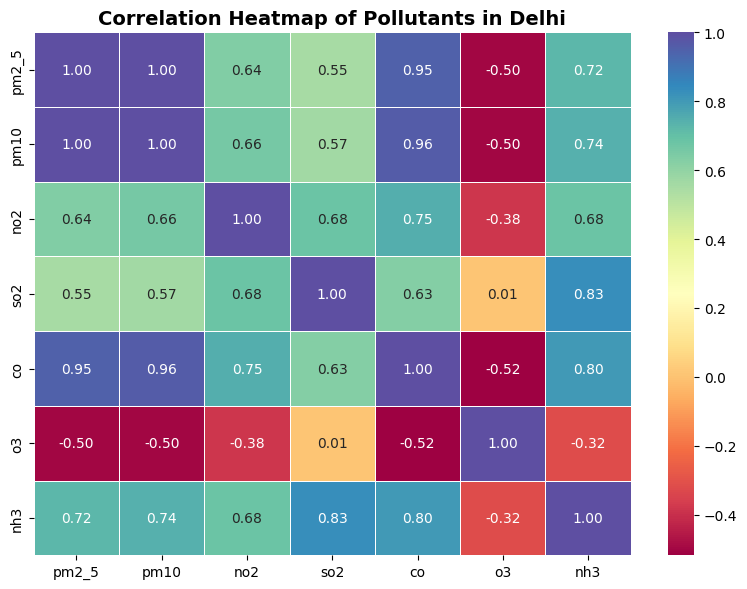

In [36]:
# What is the correlation between different pollutants?
correlation_matrix = df[['pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3']].corr()
print("--- Correlation Matrix Table ---")
display(correlation_matrix)
print("\n" + "="*50 + "\n")
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Spectral', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Pollutants in Delhi", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

--- Average PM2.5: Weekday vs Weekend ---
day_type
Weekday    448.127344
Weekend    338.654896
Name: pm2_5, dtype: float64




C:\Users\2025\AppData\Local\Temp\ipykernel_17000\3516104945.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_weekend_avg.index, y=weekday_weekend_avg.values, palette='Set2', width=0.5)


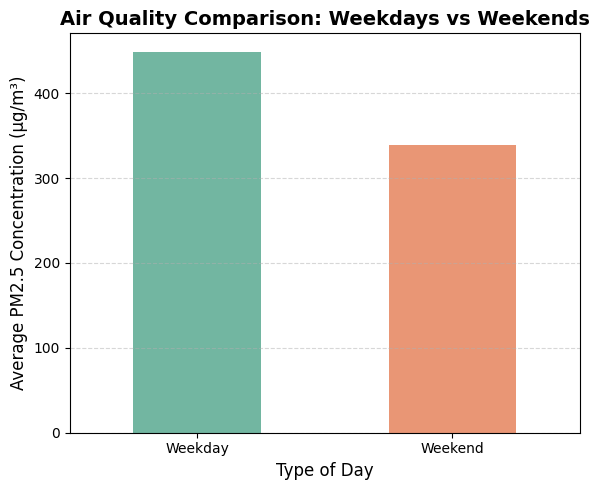

In [37]:
# How do pollution levels fluctuate between weekdays and weekends?
df['day_of_week'] = df['date'].dt.dayofweek
df['day_type'] = df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
weekday_weekend_avg = df.groupby('day_type')['pm2_5'].mean()
print("--- Average PM2.5: Weekday vs Weekend ---")
print(weekday_weekend_avg)
print("\n" + "="*50 + "\n")
plt.figure(figsize=(6, 5))
sns.barplot(x=weekday_weekend_avg.index, y=weekday_weekend_avg.values, palette='Set2', width=0.5)
plt.title("Air Quality Comparison: Weekdays vs Weekends", fontsize=14, fontweight='bold')
plt.xlabel("Type of Day", fontsize=12)
plt.ylabel("Average PM2.5 Concentration (µg/m³)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()